# Library

In [44]:
import requests
import pandas as pd
from io import StringIO
from fredapi import Fred
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_colwidth', None)
#pd.reset_option('display.max_colwidth')
pd.set_option('display.float_format', '{:.2f}'.format)
#pd.reset_option('display.float_format')

In [ ]:
# That value represents the number of households of which 
# rent takes up about 10 to 14.9 percent of their total income

In [3]:
df = pd.read_csv('/Users/minseokcho/Desktop/github/DSA_Github/lyunljl-BUDSAxNYC-SCHOOL-of-DATA_Team-A/datasets/final-usables/merged_housing_dataset.csv')
df

,geoid,name,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,...,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier
0,05000US36005,"Bronx County, NY",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,05000US36047,"Kings County, NY",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,05000US36081,"Queens County, NY",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,05000US36085,"Richmond County, NY",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,06000US3600508510,"Bronx borough, Bronx County, NY",426925.0,16598.0,29458.0,37695.0,38993.0,38592.0,35904.0,25521.0,...,4712.0,34891.0,34432.0,23907.0,25475.0,47939.0,74371.0,71994.0,55263.0,186431.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,86000US11691,11691,16665.0,1049.0,1126.0,915.0,1993.0,1893.0,1332.0,1320.0,...,276.0,925.0,2531.0,1196.0,1430.0,4074.0,3541.0,4225.0,1461.0,4413.0
254,86000US11692,11692,5400.0,342.0,471.0,405.0,408.0,251.0,426.0,560.0,...,135.0,1175.0,1307.0,361.0,275.0,1368.0,1223.0,1205.0,382.0,984.0
255,86000US11693,11693,2847.0,112.0,238.0,240.0,301.0,375.0,220.0,87.0,...,0.0,377.0,811.0,406.0,71.0,495.0,1128.0,997.0,520.0,1117.0
256,86000US11694,11694,3963.0,310.0,263.0,685.0,572.0,284.0,332.0,276.0,...,44.0,260.0,1090.0,177.0,329.0,592.0,2108.0,1046.0,560.0,2872.0


In [4]:
df.head(10)

,geoid,name,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,...,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier
0,05000US36005,"Bronx County, NY",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,05000US36047,"Kings County, NY",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,05000US36081,"Queens County, NY",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,05000US36085,"Richmond County, NY",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,06000US3600508510,"Bronx borough, Bronx County, NY",426925.0,16598.0,29458.0,37695.0,38993.0,38592.0,35904.0,25521.0,...,4712.0,34891.0,34432.0,23907.0,25475.0,47939.0,74371.0,71994.0,55263.0,186431.0
5,06000US3604710022,"Brooklyn borough, Kings County, NY",712011.0,37465.0,60852.0,81193.0,80289.0,74053.0,58016.0,41124.0,...,11355.0,80847.0,60579.0,30733.0,35547.0,55203.0,105003.0,113451.0,90305.0,517749.0
6,06000US3606144919,"Manhattan borough, New York County, NY",583299.0,38707.0,57457.0,67572.0,66243.0,59867.0,51486.0,31675.0,...,4242.0,51551.0,56191.0,31126.0,58621.0,69767.0,116832.0,80417.0,58675.0,396050.0
7,06000US3608160323,"Queens borough, Queens County, NY",463708.0,19741.0,37895.0,49728.0,52506.0,47046.0,40343.0,30998.0,...,6062.0,47469.0,40537.0,27290.0,37141.0,57419.0,119410.0,177046.0,125195.0,272637.0
8,06000US3608570915,"Staten Island borough, Richmond County, NY",55089.0,2228.0,5060.0,5515.0,4444.0,4572.0,4619.0,3556.0,...,918.0,9076.0,16844.0,18833.0,28606.0,28669.0,24087.0,17344.0,7861.0,32383.0
9,16000US3651000,"New York, NY",2241032.0,114739.0,190722.0,241703.0,242475.0,224130.0,190368.0,132874.0,...,27289.0,223834.0,208583.0,131889.0,185390.0,258997.0,439703.0,460252.0,337299.0,1405250.0


## Delete Rows (non-NYC regions)

In [6]:
df['name'].unique()

array(['Bronx County, NY', 'Kings County, NY', 'Queens County, NY',
       'Richmond County, NY', 'Bronx borough, Bronx County, NY',
       'Brooklyn borough, Kings County, NY',
       'Manhattan borough, New York County, NY',
       'Queens borough, Queens County, NY',
       'Staten Island borough, Richmond County, NY', 'New York, NY',
       '07002', '07008', '07020', '07024', '07030', '07036', '07047',
       '07064', '07077', '07086', '07093', '07202', '07206', '07302',
       '07305', '07310', '07311', '07620', '07632', '07670', '08861',
       '10001', '10002', '10003', '10004', '10005', '10006', '10007',
       '10009', '10010', '10011', '10012', '10013', '10014', '10016',
       '10017', '10018', '10019', '10020', '10021', '10022', '10023',
       '10024', '10025', '10026', '10027', '10028', '10029', '10030',
       '10031', '10032', '10033', '10034', '10035', '10036', '10037',
       '10038', '10039', '10040', '10044', '10065', '10069', '10075',
       '10103', '10110', '1011

In [7]:
df = df[pd.to_numeric(df['name'], errors='coerce').notna()]
df

,geoid,name,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,...,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier
10,86000US07002,07002,18468.0,751.0,1417.0,2058.0,2456.0,2757.0,1791.0,1038.0,...,535.0,1883.0,1717.0,848.0,1616.0,3108.0,3504.0,3601.0,2849.0,11125.0
11,86000US07008,07008,3727.0,311.0,496.0,272.0,522.0,307.0,546.0,183.0,...,101.0,594.0,1073.0,159.0,602.0,504.0,1370.0,2371.0,676.0,1297.0
12,86000US07020,07020,4348.0,210.0,314.0,661.0,319.0,372.0,800.0,197.0,...,9.0,1064.0,1970.0,1181.0,1254.0,506.0,479.0,202.0,358.0,849.0
13,86000US07024,07024,8136.0,205.0,690.0,878.0,1086.0,1057.0,553.0,469.0,...,324.0,1675.0,886.0,1279.0,2657.0,3212.0,3944.0,3396.0,1318.0,968.0
14,86000US07030,07030,18607.0,1319.0,2224.0,2976.0,3264.0,2290.0,1560.0,965.0,...,243.0,3070.0,6671.0,2359.0,2237.0,1798.0,1612.0,1475.0,1050.0,9744.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,86000US11691,11691,16665.0,1049.0,1126.0,915.0,1993.0,1893.0,1332.0,1320.0,...,276.0,925.0,2531.0,1196.0,1430.0,4074.0,3541.0,4225.0,1461.0,4413.0
254,86000US11692,11692,5400.0,342.0,471.0,405.0,408.0,251.0,426.0,560.0,...,135.0,1175.0,1307.0,361.0,275.0,1368.0,1223.0,1205.0,382.0,984.0
255,86000US11693,11693,2847.0,112.0,238.0,240.0,301.0,375.0,220.0,87.0,...,0.0,377.0,811.0,406.0,71.0,495.0,1128.0,997.0,520.0,1117.0
256,86000US11694,11694,3963.0,310.0,263.0,685.0,572.0,284.0,332.0,276.0,...,44.0,260.0,1090.0,177.0,329.0,592.0,2108.0,1046.0,560.0,2872.0


In [13]:
df['name'] = df['name'].astype(int)
df['name'].dtype

/var/folders/3z/5gfy93qs7vz0g17fs_bg32xr0000gn/T/ipykernel_31493/576281070.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['name'] = df['name'].astype(int)


dtype('int64')

In [14]:
nyc_zip_ranges = [
    (10001, 10282),  # Manhattan
    (10301, 10314),  # Staten Island
    (10451, 10475),  # Bronx
    (11101, 11106),  # Queens (part)
    (11201, 11249),  # Brooklyn
    (11354, 11697),  # Queens (part)
]

mask = pd.concat([
    (df['name'] >= low) & (df['name'] <= high)
    for low, high in nyc_zip_ranges
], axis = 1).any(axis = 1)

df = df[mask]
df

,geoid,name,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,...,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier
31,86000US10001,10001,11939.0,917.0,1502.0,1801.0,1484.0,1181.0,1074.0,546.0,...,280.0,5049.0,2404.0,296.0,590.0,423.0,3290.0,553.0,508.0,4963.0
32,86000US10002,10002,29732.0,1688.0,2438.0,2857.0,3466.0,3197.0,3752.0,1338.0,...,403.0,1940.0,1590.0,1313.0,2373.0,3566.0,4822.0,6003.0,2838.0,15848.0
33,86000US10003,10003,15410.0,1031.0,2255.0,1722.0,1455.0,1355.0,1147.0,1171.0,...,50.0,683.0,989.0,558.0,1555.0,1560.0,4611.0,2456.0,1425.0,16526.0
34,86000US10004,10004,1060.0,21.0,119.0,255.0,84.0,39.0,128.0,72.0,...,0.0,221.0,421.0,44.0,115.0,18.0,33.0,5.0,6.0,1384.0
35,86000US10005,10005,4323.0,77.0,515.0,461.0,664.0,559.0,364.0,188.0,...,0.0,161.0,841.0,601.0,125.0,515.0,393.0,339.0,218.0,3413.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,86000US11691,11691,16665.0,1049.0,1126.0,915.0,1993.0,1893.0,1332.0,1320.0,...,276.0,925.0,2531.0,1196.0,1430.0,4074.0,3541.0,4225.0,1461.0,4413.0
254,86000US11692,11692,5400.0,342.0,471.0,405.0,408.0,251.0,426.0,560.0,...,135.0,1175.0,1307.0,361.0,275.0,1368.0,1223.0,1205.0,382.0,984.0
255,86000US11693,11693,2847.0,112.0,238.0,240.0,301.0,375.0,220.0,87.0,...,0.0,377.0,811.0,406.0,71.0,495.0,1128.0,997.0,520.0,1117.0
256,86000US11694,11694,3963.0,310.0,263.0,685.0,572.0,284.0,332.0,276.0,...,44.0,260.0,1090.0,177.0,329.0,592.0,2108.0,1046.0,560.0,2872.0


In [15]:
df = df.rename(columns = {'name': 'zip'})
df

,geoid,zip,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,...,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier
31,86000US10001,10001,11939.0,917.0,1502.0,1801.0,1484.0,1181.0,1074.0,546.0,...,280.0,5049.0,2404.0,296.0,590.0,423.0,3290.0,553.0,508.0,4963.0
32,86000US10002,10002,29732.0,1688.0,2438.0,2857.0,3466.0,3197.0,3752.0,1338.0,...,403.0,1940.0,1590.0,1313.0,2373.0,3566.0,4822.0,6003.0,2838.0,15848.0
33,86000US10003,10003,15410.0,1031.0,2255.0,1722.0,1455.0,1355.0,1147.0,1171.0,...,50.0,683.0,989.0,558.0,1555.0,1560.0,4611.0,2456.0,1425.0,16526.0
34,86000US10004,10004,1060.0,21.0,119.0,255.0,84.0,39.0,128.0,72.0,...,0.0,221.0,421.0,44.0,115.0,18.0,33.0,5.0,6.0,1384.0
35,86000US10005,10005,4323.0,77.0,515.0,461.0,664.0,559.0,364.0,188.0,...,0.0,161.0,841.0,601.0,125.0,515.0,393.0,339.0,218.0,3413.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,86000US11691,11691,16665.0,1049.0,1126.0,915.0,1993.0,1893.0,1332.0,1320.0,...,276.0,925.0,2531.0,1196.0,1430.0,4074.0,3541.0,4225.0,1461.0,4413.0
254,86000US11692,11692,5400.0,342.0,471.0,405.0,408.0,251.0,426.0,560.0,...,135.0,1175.0,1307.0,361.0,275.0,1368.0,1223.0,1205.0,382.0,984.0
255,86000US11693,11693,2847.0,112.0,238.0,240.0,301.0,375.0,220.0,87.0,...,0.0,377.0,811.0,406.0,71.0,495.0,1128.0,997.0,520.0,1117.0
256,86000US11694,11694,3963.0,310.0,263.0,685.0,572.0,284.0,332.0,276.0,...,44.0,260.0,1090.0,177.0,329.0,592.0,2108.0,1046.0,560.0,2872.0


## Borough Identifier

In [16]:
def get_borough(zip_code):
    if 10001 <= zip_code <= 10282:
        return 'Manhattan'
    elif 10301 <= zip_code <= 10314:
        return 'Staten Island'
    elif 10451 <= zip_code <= 10475:
        return 'Bronx'
    elif 11201 <= zip_code <= 11249:
        return 'Brooklyn'
    elif (11101 <= zip_code <= 11106) or (11354 <= zip_code <= 11697):
        return 'Queens'
    else:
        return None  # Non-NYC zip codes

df['borough'] = df['zip'].apply(get_borough)
df

,geoid,zip,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,...,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier,borough
31,86000US10001,10001,11939.0,917.0,1502.0,1801.0,1484.0,1181.0,1074.0,546.0,...,5049.0,2404.0,296.0,590.0,423.0,3290.0,553.0,508.0,4963.0,Manhattan
32,86000US10002,10002,29732.0,1688.0,2438.0,2857.0,3466.0,3197.0,3752.0,1338.0,...,1940.0,1590.0,1313.0,2373.0,3566.0,4822.0,6003.0,2838.0,15848.0,Manhattan
33,86000US10003,10003,15410.0,1031.0,2255.0,1722.0,1455.0,1355.0,1147.0,1171.0,...,683.0,989.0,558.0,1555.0,1560.0,4611.0,2456.0,1425.0,16526.0,Manhattan
34,86000US10004,10004,1060.0,21.0,119.0,255.0,84.0,39.0,128.0,72.0,...,221.0,421.0,44.0,115.0,18.0,33.0,5.0,6.0,1384.0,Manhattan
35,86000US10005,10005,4323.0,77.0,515.0,461.0,664.0,559.0,364.0,188.0,...,161.0,841.0,601.0,125.0,515.0,393.0,339.0,218.0,3413.0,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,86000US11691,11691,16665.0,1049.0,1126.0,915.0,1993.0,1893.0,1332.0,1320.0,...,925.0,2531.0,1196.0,1430.0,4074.0,3541.0,4225.0,1461.0,4413.0,Queens
254,86000US11692,11692,5400.0,342.0,471.0,405.0,408.0,251.0,426.0,560.0,...,1175.0,1307.0,361.0,275.0,1368.0,1223.0,1205.0,382.0,984.0,Queens
255,86000US11693,11693,2847.0,112.0,238.0,240.0,301.0,375.0,220.0,87.0,...,377.0,811.0,406.0,71.0,495.0,1128.0,997.0,520.0,1117.0,Queens
256,86000US11694,11694,3963.0,310.0,263.0,685.0,572.0,284.0,332.0,276.0,...,260.0,1090.0,177.0,329.0,592.0,2108.0,1046.0,560.0,2872.0,Queens


In [21]:
zip_idx = df.columns.get_loc('zip')
cols = list(df.columns)
cols.remove('borough')
cols.insert(zip_idx + 1, 'borough')
df = df[cols]
df

,geoid,zip,borough,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,rent_not_computed,housing_units_total,median_gross_rent,median_household_income,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier
31,86000US10001,10001,Manhattan,11939.00,917.00,1502.00,1801.00,1484.00,1181.00,1074.00,546.00,892.00,2137.00,405.00,18356.00,3361.00,129852.00,18356.00,15737.00,2619.00,15737.00,3798.00,11939.00,30511.00,18356.00,280.00,5049.00,2404.00,296.00,590.00,423.00,3290.00,553.00,508.00,4963.00
32,86000US10002,10002,Manhattan,29732.00,1688.00,2438.00,2857.00,3466.00,3197.00,3752.00,1338.00,2076.00,7758.00,1162.00,40696.00,1229.00,48386.00,40696.00,36556.00,4140.00,36556.00,6824.00,29732.00,76873.00,40696.00,403.00,1940.00,1590.00,1313.00,2373.00,3566.00,4822.00,6003.00,2838.00,15848.00
33,86000US10003,10003,Manhattan,15410.00,1031.00,2255.00,1722.00,1455.00,1355.00,1147.00,1171.00,1148.00,3480.00,646.00,30413.00,3049.00,154262.00,30413.00,24503.00,5910.00,24503.00,9093.00,15410.00,53560.00,30413.00,50.00,683.00,989.00,558.00,1555.00,1560.00,4611.00,2456.00,1425.00,16526.00
34,86000US10004,10004,Manhattan,1060.00,21.00,119.00,255.00,84.00,39.00,128.00,72.00,136.00,206.00,0.00,2247.00,3501.00,250001.00,2247.00,1865.00,382.00,1865.00,805.00,1060.00,3711.00,2247.00,0.00,221.00,421.00,44.00,115.00,18.00,33.00,5.00,6.00,1384.00
35,86000US10005,10005,Manhattan,4323.00,77.00,515.00,461.00,664.00,559.00,364.00,188.00,331.00,1164.00,0.00,6606.00,3501.00,190233.00,6606.00,5248.00,1358.00,5248.00,925.00,4323.00,9439.00,6606.00,0.00,161.00,841.00,601.00,125.00,515.00,393.00,339.00,218.00,3413.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,86000US11691,11691,Queens,16665.00,1049.00,1126.00,915.00,1993.00,1893.00,1332.00,1320.00,1426.00,4702.00,909.00,24072.00,1425.00,56135.00,24072.00,23039.00,1033.00,23039.00,6374.00,16665.00,69359.00,24072.00,276.00,925.00,2531.00,1196.00,1430.00,4074.00,3541.00,4225.00,1461.00,4413.00
254,86000US11692,11692,Queens,5400.00,342.00,471.00,405.00,408.00,251.00,426.00,560.00,412.00,1734.00,391.00,8415.00,1161.00,49720.00,8415.00,8070.00,345.00,8070.00,2670.00,5400.00,22734.00,8415.00,135.00,1175.00,1307.00,361.00,275.00,1368.00,1223.00,1205.00,382.00,984.00
255,86000US11693,11693,Queens,2847.00,112.00,238.00,240.00,301.00,375.00,220.00,87.00,171.00,907.00,196.00,5922.00,1216.00,68449.00,5922.00,5559.00,363.00,5559.00,2712.00,2847.00,13244.00,5922.00,0.00,377.00,811.00,406.00,71.00,495.00,1128.00,997.00,520.00,1117.00
256,86000US11694,11694,Queens,3963.00,310.00,263.00,685.00,572.00,284.00,332.00,276.00,127.00,816.00,298.00,9078.00,1757.00,111011.00,9078.00,8165.00,913.00,8165.00,4202.00,3963.00,21489.00,9078.00,44.00,260.00,1090.00,177.00,329.00,592.00,2108.00,1046.00,560.00,2872.00


## Check missing values

In [24]:
df.isnull().sum().to_frame('missing').assign(
    pct=lambda x: (x['missing'] / len(df) * 100).round(2)
)

,missing,pct
geoid,0,0.00
zip,0,0.00
borough,0,0.00
rent_burden_total_renter_households,0,0.00
rent_lt_10pct_income,0,0.00
rent_10_to_14_9pct_income,0,0.00
rent_15_to_19_9pct_income,0,0.00
rent_20_to_24_9pct_income,0,0.00
rent_25_to_29_9pct_income,0,0.00
rent_30_to_34_9pct_income,0,0.00


## Negative Values?

In [64]:
exclude_cols = ['geoid', 'zip', 'borough']
check_cols = df.columns.difference(exclude_cols)

df[df[check_cols].lt(0).any(axis=1)]

,geoid,zip,borough,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,rent_not_computed,housing_units_total,median_gross_rent,median_household_income,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier
48,86000US10020,10020,Manhattan,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-666666700.00,-666666700.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
73,86000US10103,10103,Manhattan,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-666666700.00,-666666700.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
74,86000US10110,10110,Manhattan,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-666666700.00,-666666700.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75,86000US10111,10111,Manhattan,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-666666700.00,-666666700.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
76,86000US10112,10112,Manhattan,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-666666700.00,-666666700.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
77,86000US10115,10115,Manhattan,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-666666700.00,-666666700.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
78,86000US10119,10119,Manhattan,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-666666700.00,-666666700.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
80,86000US10152,10152,Manhattan,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,87.00,-666666700.00,-666666700.00,87.00,4.00,83.00,4.00,4.00,0.00,7.00,87.00,0.00,30.00,23.00,0.00,0.00,0.00,0.00,0.00,12.00,22.00
81,86000US10153,10153,Manhattan,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-666666700.00,-666666700.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
82,86000US10154,10154,Manhattan,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-666666700.00,-666666700.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [65]:
df[check_cols] = df[check_cols].where(df[check_cols] >= 0, other = None)

## Categorize the Columns

In [55]:
df_condense = df.copy()
df_condense['rent<20'] = df_condense['rent_lt_10pct_income'] + df_condense['rent_10_to_14_9pct_income'] + df_condense['rent_15_to_19_9pct_income']
df_condense['20<=rent<40'] = df_condense['rent_20_to_24_9pct_income'] + df_condense['rent_25_to_29_9pct_income'] + df_condense['rent_30_to_34_9pct_income'] + df_condense['rent_35_to_39_9pct_income']
df_condense['40<=rent'] = df_condense['rent_40_to_49_9pct_income'] + df_condense['rent_50pct_or_more_income']
df_condense = df_condense.drop(columns = df_condense.columns[4:13])

cols = list(df_condense.columns)
for col in ['rent<20', '20<=rent<40', '40<=rent']:
    cols.remove(col)
cols.insert(4, 'rent<20')
cols.insert(5, '20<=rent<40')
cols.insert(6, '40<=rent')

df_condense = df_condense[cols]

df_condense

,geoid,zip,borough,rent_burden_total_renter_households,rent<20,20<=rent<40,40<=rent,rent_not_computed,housing_units_total,median_gross_rent,median_household_income,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier
31,86000US10001,10001,Manhattan,11939.00,4220.00,4285.00,3029.00,405.00,18356.00,3361.00,129852.00,18356.00,15737.00,2619.00,15737.00,3798.00,11939.00,30511.00,18356.00,280.00,5049.00,2404.00,296.00,590.00,423.00,3290.00,553.00,508.00,4963.00
32,86000US10002,10002,Manhattan,29732.00,6983.00,11753.00,9834.00,1162.00,40696.00,1229.00,48386.00,40696.00,36556.00,4140.00,36556.00,6824.00,29732.00,76873.00,40696.00,403.00,1940.00,1590.00,1313.00,2373.00,3566.00,4822.00,6003.00,2838.00,15848.00
33,86000US10003,10003,Manhattan,15410.00,5008.00,5128.00,4628.00,646.00,30413.00,3049.00,154262.00,30413.00,24503.00,5910.00,24503.00,9093.00,15410.00,53560.00,30413.00,50.00,683.00,989.00,558.00,1555.00,1560.00,4611.00,2456.00,1425.00,16526.00
34,86000US10004,10004,Manhattan,1060.00,395.00,323.00,342.00,0.00,2247.00,3501.00,250001.00,2247.00,1865.00,382.00,1865.00,805.00,1060.00,3711.00,2247.00,0.00,221.00,421.00,44.00,115.00,18.00,33.00,5.00,6.00,1384.00
35,86000US10005,10005,Manhattan,4323.00,1053.00,1775.00,1495.00,0.00,6606.00,3501.00,190233.00,6606.00,5248.00,1358.00,5248.00,925.00,4323.00,9439.00,6606.00,0.00,161.00,841.00,601.00,125.00,515.00,393.00,339.00,218.00,3413.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,86000US11691,11691,Queens,16665.00,3090.00,6538.00,6128.00,909.00,24072.00,1425.00,56135.00,24072.00,23039.00,1033.00,23039.00,6374.00,16665.00,69359.00,24072.00,276.00,925.00,2531.00,1196.00,1430.00,4074.00,3541.00,4225.00,1461.00,4413.00
254,86000US11692,11692,Queens,5400.00,1218.00,1645.00,2146.00,391.00,8415.00,1161.00,49720.00,8415.00,8070.00,345.00,8070.00,2670.00,5400.00,22734.00,8415.00,135.00,1175.00,1307.00,361.00,275.00,1368.00,1223.00,1205.00,382.00,984.00
255,86000US11693,11693,Queens,2847.00,590.00,983.00,1078.00,196.00,5922.00,1216.00,68449.00,5922.00,5559.00,363.00,5559.00,2712.00,2847.00,13244.00,5922.00,0.00,377.00,811.00,406.00,71.00,495.00,1128.00,997.00,520.00,1117.00
256,86000US11694,11694,Queens,3963.00,1258.00,1464.00,943.00,298.00,9078.00,1757.00,111011.00,9078.00,8165.00,913.00,8165.00,4202.00,3963.00,21489.00,9078.00,44.00,260.00,1090.00,177.00,329.00,592.00,2108.00,1046.00,560.00,2872.00


# Visualization (df)

In [66]:
df['median_household_income'].describe()

count      182.00
mean     97758.40
std      45209.97
min      24086.00
25%      67789.75
50%      88703.00
75%     117944.50
max     250001.00
Name: median_household_income, dtype: float64

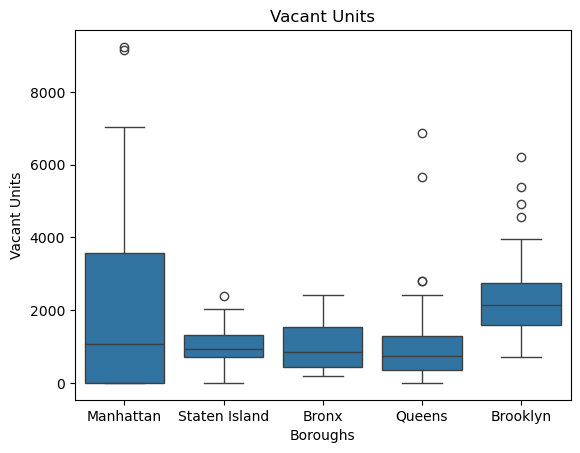

In [67]:
# Med Gross Rent
sns.boxplot(data=df, x='borough', y='vacant_units')
plt.title("Vacant Units")
plt.xlabel("Boroughs")
plt.ylabel("Vacant Units")
plt.show()

<Axes: xlabel='borough', ylabel='median_household_income'>

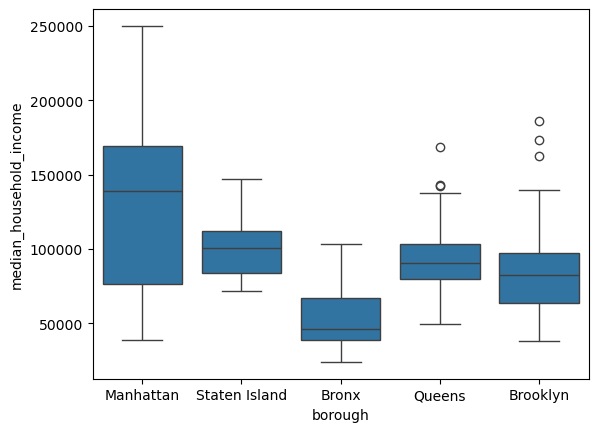

In [68]:
# Median Household Income
sns.boxplot(data=df, x='borough', y='median_household_income')

# (Additional) Make Data groupby Borough

In [69]:
df.columns
# all sum, except the 
# "median_gross_rent", "median_houshold_income", 
# and after summing all up, try convert some things to percentage?

Index(['geoid', 'zip', 'borough', 'rent_burden_total_renter_households',
       'rent_lt_10pct_income', 'rent_10_to_14_9pct_income',
       'rent_15_to_19_9pct_income', 'rent_20_to_24_9pct_income',
       'rent_25_to_29_9pct_income', 'rent_30_to_34_9pct_income',
       'rent_35_to_39_9pct_income', 'rent_40_to_49_9pct_income',
       'rent_50pct_or_more_income', 'rent_not_computed', 'housing_units_total',
       'median_gross_rent', 'median_household_income', 'occupancy_total_units',
       'occupied_units', 'vacant_units', 'tenure_total_occupied_units',
       'owner_occupied_units', 'renter_occupied_units', 'total_population',
       'year_built_total_units', 'built_2020_or_later', 'built_2010_2019',
       'built_2000_2009', 'built_1990_1999', 'built_1980_1989',
       'built_1970_1979', 'built_1960_1969', 'built_1950_1959',
       'built_1940_1949', 'built_1939_or_earlier'],
      dtype='object')

In [70]:
# df_br = df.groupby('borough').sum().reset_index()
# df_br
sum_cols = [c for c in df.columns if c not in ['borough', "median_gross_rent", "median_household_income"]]
agg_dict = {col: 'sum' for col in sum_cols}
agg_dict.update({"median_gross_rent": 'mean', "median_household_income": 'mean'})

df_br = df.groupby('borough').agg(agg_dict).reset_index()
df_br

,borough,geoid,zip,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,rent_not_computed,housing_units_total,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier,median_gross_rent,median_household_income
0,Bronx,86000US1045186000US1045286000US1045386000US104...,261575,429990.00,16652.00,29616.00,38031.00,39318.00,38745.00,36164.00,25729.00,36917.00,145987.00,22831.00,563117.00,563117.00,537455.00,25662.00,537455.00,107465.00,429990.00,1412082.00,563117.00,4712.00,34891.00,34501.00,24087.00,25547.00,48146.00,74953.00,72662.00,55559.00,188059.00,1482.60,55548.72
1,Brooklyn,86000US1120186000US1120386000US1120486000US112...,426400,712011.00,37465.00,60852.00,81193.00,80289.00,74053.00,58016.00,41124.00,55091.00,190739.00,33189.00,1100722.00,1100722.00,1009877.00,90845.00,1009877.00,297866.00,712011.00,2631396.00,1100722.00,11355.00,80847.00,60579.00,30733.00,35547.00,55203.00,105003.00,113432.00,90305.00,517718.00,1959.58,87958.92
2,Manhattan,86000US1000186000US1000286000US1000386000US100...,695764,580234.00,38653.00,57299.00,67236.00,65918.00,59714.00,51226.00,31467.00,42671.00,140355.00,25695.00,919770.00,919770.00,774926.00,144844.00,774926.00,194692.00,580234.00,1619224.00,919770.00,4242.00,51551.00,56122.00,30946.00,58549.00,69560.00,116250.00,79749.00,58379.00,394422.00,2638.17,132305.93
3,Queens,86000US1110186000US1110286000US1110386000US111...,763900,462508.00,19324.00,37696.00,49345.00,52198.00,46662.00,40359.00,31118.00,37621.00,123668.00,24517.00,920477.00,920477.00,851780.00,68697.00,851780.00,389272.00,462508.00,2372897.00,920477.00,6097.00,46085.00,39598.00,26902.00,37428.00,57075.00,122017.00,181291.00,126836.00,277148.00,2016.75,94498.77
4,Staten Island,86000US1030186000US1030286000US1030386000US103...,133992,55089.00,2228.00,5060.00,5515.00,4444.00,4572.00,4619.00,3556.00,4298.00,16185.00,4612.00,184621.00,184621.00,170777.00,13844.00,170777.00,115688.00,55089.00,494956.00,184621.00,918.00,9076.00,16844.00,18833.00,28606.00,28669.00,24087.00,17344.00,7861.00,32383.00,1760.42,100864.42


In [71]:
df_br = df_br.drop(columns = ['geoid', 'zip'])
df_br

,borough,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,rent_not_computed,housing_units_total,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier,median_gross_rent,median_household_income
0,Bronx,429990.00,16652.00,29616.00,38031.00,39318.00,38745.00,36164.00,25729.00,36917.00,145987.00,22831.00,563117.00,563117.00,537455.00,25662.00,537455.00,107465.00,429990.00,1412082.00,563117.00,4712.00,34891.00,34501.00,24087.00,25547.00,48146.00,74953.00,72662.00,55559.00,188059.00,1482.60,55548.72
1,Brooklyn,712011.00,37465.00,60852.00,81193.00,80289.00,74053.00,58016.00,41124.00,55091.00,190739.00,33189.00,1100722.00,1100722.00,1009877.00,90845.00,1009877.00,297866.00,712011.00,2631396.00,1100722.00,11355.00,80847.00,60579.00,30733.00,35547.00,55203.00,105003.00,113432.00,90305.00,517718.00,1959.58,87958.92
2,Manhattan,580234.00,38653.00,57299.00,67236.00,65918.00,59714.00,51226.00,31467.00,42671.00,140355.00,25695.00,919770.00,919770.00,774926.00,144844.00,774926.00,194692.00,580234.00,1619224.00,919770.00,4242.00,51551.00,56122.00,30946.00,58549.00,69560.00,116250.00,79749.00,58379.00,394422.00,2638.17,132305.93
3,Queens,462508.00,19324.00,37696.00,49345.00,52198.00,46662.00,40359.00,31118.00,37621.00,123668.00,24517.00,920477.00,920477.00,851780.00,68697.00,851780.00,389272.00,462508.00,2372897.00,920477.00,6097.00,46085.00,39598.00,26902.00,37428.00,57075.00,122017.00,181291.00,126836.00,277148.00,2016.75,94498.77
4,Staten Island,55089.00,2228.00,5060.00,5515.00,4444.00,4572.00,4619.00,3556.00,4298.00,16185.00,4612.00,184621.00,184621.00,170777.00,13844.00,170777.00,115688.00,55089.00,494956.00,184621.00,918.00,9076.00,16844.00,18833.00,28606.00,28669.00,24087.00,17344.00,7861.00,32383.00,1760.42,100864.42


In [72]:
# change columns names for the two:
# "median_gross_rent", "median_houshold_income"
df_br = df_br.rename(columns = {'median_gross_rent': "avg_median_gross_rent", 
                                'median_household_income': "avg_median_houshold_income"})

df_br

,borough,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,rent_not_computed,housing_units_total,occupancy_total_units,occupied_units,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier,avg_median_gross_rent,avg_median_houshold_income
0,Bronx,429990.00,16652.00,29616.00,38031.00,39318.00,38745.00,36164.00,25729.00,36917.00,145987.00,22831.00,563117.00,563117.00,537455.00,25662.00,537455.00,107465.00,429990.00,1412082.00,563117.00,4712.00,34891.00,34501.00,24087.00,25547.00,48146.00,74953.00,72662.00,55559.00,188059.00,1482.60,55548.72
1,Brooklyn,712011.00,37465.00,60852.00,81193.00,80289.00,74053.00,58016.00,41124.00,55091.00,190739.00,33189.00,1100722.00,1100722.00,1009877.00,90845.00,1009877.00,297866.00,712011.00,2631396.00,1100722.00,11355.00,80847.00,60579.00,30733.00,35547.00,55203.00,105003.00,113432.00,90305.00,517718.00,1959.58,87958.92
2,Manhattan,580234.00,38653.00,57299.00,67236.00,65918.00,59714.00,51226.00,31467.00,42671.00,140355.00,25695.00,919770.00,919770.00,774926.00,144844.00,774926.00,194692.00,580234.00,1619224.00,919770.00,4242.00,51551.00,56122.00,30946.00,58549.00,69560.00,116250.00,79749.00,58379.00,394422.00,2638.17,132305.93
3,Queens,462508.00,19324.00,37696.00,49345.00,52198.00,46662.00,40359.00,31118.00,37621.00,123668.00,24517.00,920477.00,920477.00,851780.00,68697.00,851780.00,389272.00,462508.00,2372897.00,920477.00,6097.00,46085.00,39598.00,26902.00,37428.00,57075.00,122017.00,181291.00,126836.00,277148.00,2016.75,94498.77
4,Staten Island,55089.00,2228.00,5060.00,5515.00,4444.00,4572.00,4619.00,3556.00,4298.00,16185.00,4612.00,184621.00,184621.00,170777.00,13844.00,170777.00,115688.00,55089.00,494956.00,184621.00,918.00,9076.00,16844.00,18833.00,28606.00,28669.00,24087.00,17344.00,7861.00,32383.00,1760.42,100864.42


In [73]:
cols = list(df_br.columns)

cols.remove('avg_median_gross_rent')
cols.remove('avg_median_houshold_income')

cols.insert(15, 'avg_median_gross_rent')
cols.insert(16, 'avg_median_houshold_income')

df_br = df_br[cols]
df_br

,borough,rent_burden_total_renter_households,rent_lt_10pct_income,rent_10_to_14_9pct_income,rent_15_to_19_9pct_income,rent_20_to_24_9pct_income,rent_25_to_29_9pct_income,rent_30_to_34_9pct_income,rent_35_to_39_9pct_income,rent_40_to_49_9pct_income,rent_50pct_or_more_income,rent_not_computed,housing_units_total,occupancy_total_units,occupied_units,avg_median_gross_rent,avg_median_houshold_income,vacant_units,tenure_total_occupied_units,owner_occupied_units,renter_occupied_units,total_population,year_built_total_units,built_2020_or_later,built_2010_2019,built_2000_2009,built_1990_1999,built_1980_1989,built_1970_1979,built_1960_1969,built_1950_1959,built_1940_1949,built_1939_or_earlier
0,Bronx,429990.00,16652.00,29616.00,38031.00,39318.00,38745.00,36164.00,25729.00,36917.00,145987.00,22831.00,563117.00,563117.00,537455.00,1482.60,55548.72,25662.00,537455.00,107465.00,429990.00,1412082.00,563117.00,4712.00,34891.00,34501.00,24087.00,25547.00,48146.00,74953.00,72662.00,55559.00,188059.00
1,Brooklyn,712011.00,37465.00,60852.00,81193.00,80289.00,74053.00,58016.00,41124.00,55091.00,190739.00,33189.00,1100722.00,1100722.00,1009877.00,1959.58,87958.92,90845.00,1009877.00,297866.00,712011.00,2631396.00,1100722.00,11355.00,80847.00,60579.00,30733.00,35547.00,55203.00,105003.00,113432.00,90305.00,517718.00
2,Manhattan,580234.00,38653.00,57299.00,67236.00,65918.00,59714.00,51226.00,31467.00,42671.00,140355.00,25695.00,919770.00,919770.00,774926.00,2638.17,132305.93,144844.00,774926.00,194692.00,580234.00,1619224.00,919770.00,4242.00,51551.00,56122.00,30946.00,58549.00,69560.00,116250.00,79749.00,58379.00,394422.00
3,Queens,462508.00,19324.00,37696.00,49345.00,52198.00,46662.00,40359.00,31118.00,37621.00,123668.00,24517.00,920477.00,920477.00,851780.00,2016.75,94498.77,68697.00,851780.00,389272.00,462508.00,2372897.00,920477.00,6097.00,46085.00,39598.00,26902.00,37428.00,57075.00,122017.00,181291.00,126836.00,277148.00
4,Staten Island,55089.00,2228.00,5060.00,5515.00,4444.00,4572.00,4619.00,3556.00,4298.00,16185.00,4612.00,184621.00,184621.00,170777.00,1760.42,100864.42,13844.00,170777.00,115688.00,55089.00,494956.00,184621.00,918.00,9076.00,16844.00,18833.00,28606.00,28669.00,24087.00,17344.00,7861.00,32383.00


In [74]:
df_br['avg_median_houshold_income'].describe()

count        5.00
mean     94235.35
std      27520.14
min      55548.72
25%      87958.92
50%      94498.77
75%     100864.42
max     132305.93
Name: avg_median_houshold_income, dtype: float64

# Categorize the Columns?

In [41]:
df_br.columns


Index(['borough', 'rent_burden_total_renter_households',
       'rent_lt_10pct_income', 'rent_10_to_14_9pct_income',
       'rent_15_to_19_9pct_income', 'rent_20_to_24_9pct_income',
       'rent_25_to_29_9pct_income', 'rent_30_to_34_9pct_income',
       'rent_35_to_39_9pct_income', 'rent_40_to_49_9pct_income',
       'rent_50pct_or_more_income', 'rent_not_computed', 'housing_units_total',
       'occupancy_total_units', 'occupied_units', 'avg_median_gross_rent',
       'avg_median_houshold_income', 'vacant_units',
       'tenure_total_occupied_units', 'owner_occupied_units',
       'renter_occupied_units', 'total_population', 'year_built_total_units',
       'built_2020_or_later', 'built_2010_2019', 'built_2000_2009',
       'built_1990_1999', 'built_1980_1989', 'built_1970_1979',
       'built_1960_1969', 'built_1950_1959', 'built_1940_1949',
       'built_1939_or_earlier'],
      dtype='object')

# Simple Viz (df_br)

In [ ]:
# Avg Median Gross Rent per Borough



# Revised Data Download

In [75]:
df.to_csv("Revised - Merged Housing Dataset (by ZipCode).csv")
df_br.to_csv("Revised - Merged Housing Dataset (by Borough).csv")